In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load the dataset metadata
dataset_file = 'organized_image_data_with_categories.csv'  # Adjust the file path if necessary
metadata = pd.read_csv(dataset_file)

# Display the first few rows to confirm it's loaded correctly
print(metadata.head())


                                          image_path  category file_extension  \
0  /Users/adrian/Documents/cubicasa5k/colorful/66...  colorful           .png   
1  /Users/adrian/Documents/cubicasa5k/colorful/66...  colorful           .png   
2  /Users/adrian/Documents/cubicasa5k/colorful/66...  colorful           .png   
3  /Users/adrian/Documents/cubicasa5k/colorful/66...  colorful           .png   
4  /Users/adrian/Documents/cubicasa5k/colorful/96...  colorful           .png   

     image_size image_mode  
0    (504, 430)        RGB  
1  (1374, 1172)        RGB  
2  (1374, 1172)        RGB  
3    (504, 430)        RGB  
4   (1669, 953)        RGB  


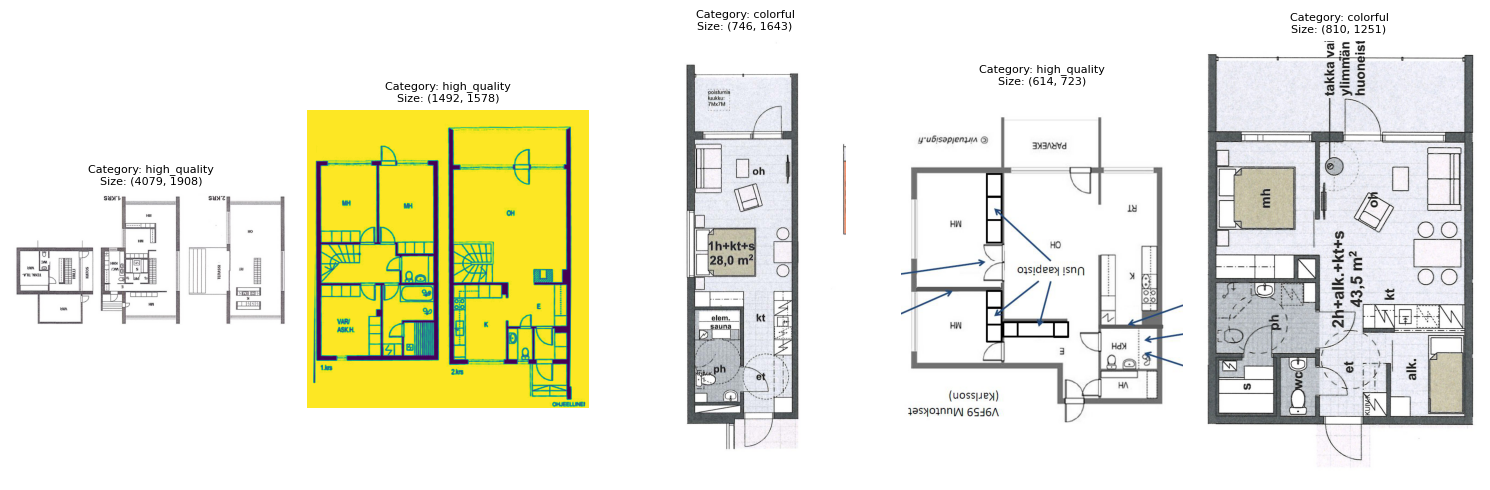

In [2]:
# Function to display random images
def show_random_images(metadata, num_images=5):
    
    # Randomly sample the dataset
    sample_data = metadata.sample(n=num_images)

    # Set up the plot
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for ax, (_, row) in zip(axes, sample_data.iterrows()):
        # Load and display the image
        img = Image.open(row['image_path'])
        ax.imshow(img)
        ax.axis('off')
        # Add category and size info
        ax.set_title(f"Category: {row['category']}\nSize: {row['image_size']}", fontsize=8)

    plt.tight_layout()
    plt.show()

# Show 5 random images from the dataset
show_random_images(metadata, num_images=5)


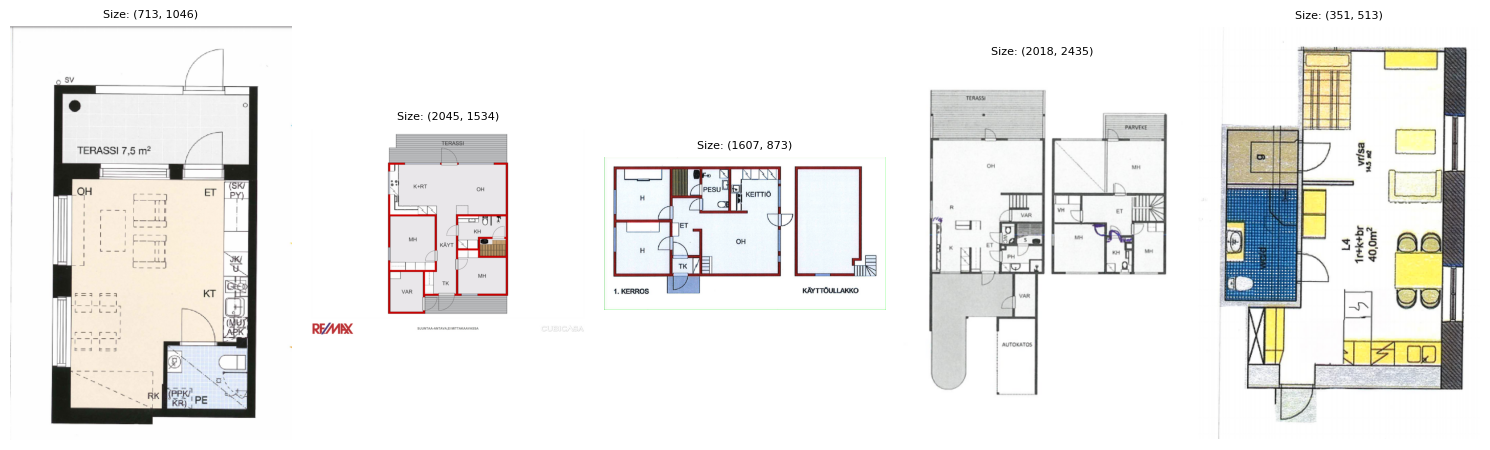

In [3]:
# Function to show images from a specific category
def show_images_by_category(metadata, category, num_images=5):
    
    # Filter metadata for the given category
    category_data = metadata[metadata['category'] == category]
    
    # Sample images from the category
    sample_data = category_data.sample(n=num_images)
    
    # Set up the plot
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for ax, (_, row) in zip(axes, sample_data.iterrows()):
        # Load and display the image
        img = Image.open(row['image_path'])
        ax.imshow(img)
        ax.axis('off')
        # Add image details
        ax.set_title(f"Size: {row['image_size']}", fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Show images from the "colorful" category
show_images_by_category(metadata, category='colorful', num_images=5)


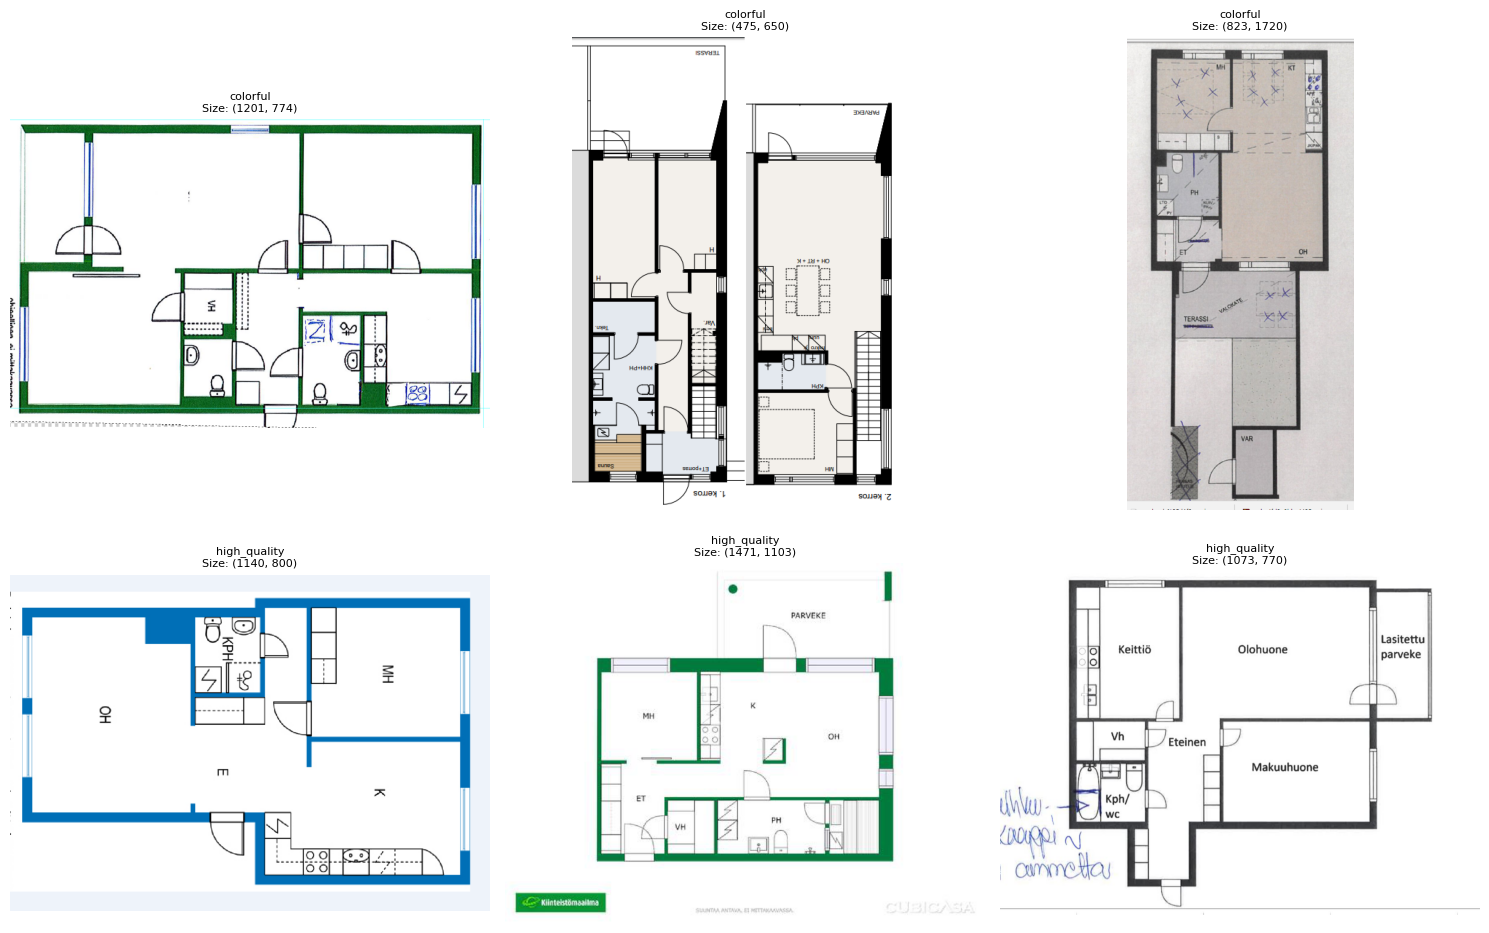

In [4]:
# Function to show side-by-side images from multiple categories
def compare_categories(metadata, categories, num_images=3):
    
    fig, axes = plt.subplots(len(categories), num_images, figsize=(15, len(categories) * 5))

    for i, category in enumerate(categories):
        # Filter metadata for the given category
        category_data = metadata[metadata['category'] == category]
        # Sample images from the category
        sample_data = category_data.sample(n=num_images)

        for ax, (_, row) in zip(axes[i] if len(categories) > 1 else [axes], sample_data.iterrows()):
            # Load and display the image
            img = Image.open(row['image_path'])
            ax.imshow(img)
            ax.axis('off')
            # Add category info
            ax.set_title(f"{category}\nSize: {row['image_size']}", fontsize=8)

    plt.tight_layout()
    plt.show()

# Compare images from "colorful" and "high_quality" categories
compare_categories(metadata, categories=['colorful', 'high_quality'], num_images=3)
